# Práctica 6 de resolución numérica de sistemas no lineales

## Resolución con `fp.findroot`

Recordemos que con la función `raices` de la práctica anterior podemos ver un dibujo de las raíces de una función de dos variables y dos componentes. 

In [29]:
def raices(f, x0=-5, x1=5, y0=-5, y1=5):
    var('x y')
    opts = {'fill':False, 'contours':[0]}
    g1 = contour_plot(f(x,y)[0], (x, x0, x1), (y, y0, y1), cmap=['blue'],  **opts)
    g2 = contour_plot(f(x,y)[1], (x, x0, x1), (y, y0, y1), cmap=['green'], **opts)
    return g1+g2

Por ejemplo, la función 
$\displaystyle \mathbf{f}(x,y) = \left(\begin{array}{c} x-y^2+1\\ x^2+y^2-3 \end{array}\right)$
 presenta dos raíces cerca de $(1, -1.4)$ y $(1, 1.4)$.

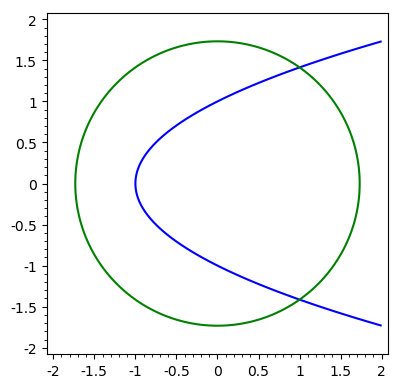

In [30]:
f = lambda x,y: [x-y^2+1, x^2+y^2-3]
raices(f, -2,2, -2,2)

La función `findroot` debe cargarse desde el módulo de punto flotante `fp`, del paquete de cálculo matemático con precisión múltiple `mpmath`. Además de la función, debe indicarse un iterante inicial.

In [31]:
from mpmath import fp
P = [0.1, 0.15]
sol = fp.findroot(f, P)
sol

matrix(
[['1.0000000000000004'],
 ['1.4142135623730954']])

El resultado se devuelve en un tipo de dato propio de `mpmath`. Puede transformarse a un vector numérico de SageMath con `vector`.

In [32]:
vector(RDF, sol)

(1.0000000000000004, 1.4142135623730954)

**Ejercicio 1:**
1. Pinta las raíces de $\displaystyle \mathbf{f}(x,y) = \left(\begin{array}{c} x^2-y^2+2y\\ 2x+y^2-6 \end{array}\right)$ en $[-5,5]\times[-5,5]$, usando `raices`.
2. Identifica con precisión al menos dos de sus raíces, usando `fp.findroot`

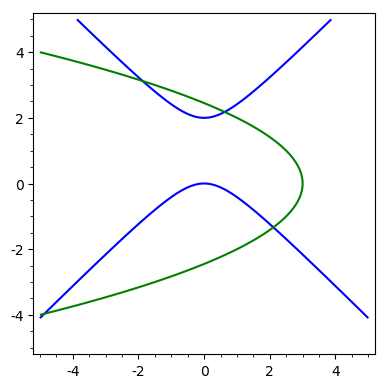

In [33]:
f = lambda x,y: [x^2-y^2+2*y, 2*x+y^2-6]
raices(f)

In [34]:
vector(RDF, fp.findroot(f, [-4,-4]))

(-4.864167848788669, -3.965896581805608)

In [35]:
vector(RDF,fp.findroot(f, [2,2]))

(0.6252040952123118, 2.1793558244525797)

## El método de Newton
El método de Newton también permite hallar raíces de funciones vectoriales.

In [36]:
def newton(f, df, x0, xtol=1e-12, rtol=1e-14, M=100):
    """NEWTON    Calculo de raices por Newton multidimensional."""
    v = [vector(RDF,x0)]
    for k in range(M):
        dfx = matrix(RDF,df(*v[k]))
        if rank(dfx) < len(x0):
            raise RuntimeError('La matriz jacobiana es singular en un iterante.')
        r = v[k] - dfx.solve_right(vector(RDF,f(*v[k])));
        v.append(r)
        # test de parada
        if norm(r - v[k]) < xtol or norm(vector(RDF,f(*r))) < rtol:
            return r, len(v), v
    raise RuntimeError('Excedido el número máximo de iteraciones.')

Para acceder a las componentes de un vector, debemos usar el operador de desempaquetamiento de listas `*`.

In [37]:
f  = lambda x,y: [x-y^2+1, x^2+y^2-3]
v = [1, 2]
f(*v) # f(v) daría un error al pasarle solo un argumento

[-2, 2]

En caso de que la función sea derivable, podemos usar el comando de cálculo simbólico `jacobian` para conseguir la matriz jacobiana. Hay que señalar que lo óptimo sería escribirla "a mano" para evitar recalcularla en cada llamada.

In [38]:
var('x y')
df = lambda a,b: jacobian(f(x,y), [x,y])(x=a, y=b)
newton(f, df, [1,1])

((1.0, 1.4142135623730951),
 6,
 [(1.0, 1.0),
  (1.0, 1.5),
  (1.0, 1.4166666666666667),
  (1.0, 1.4142156862745099),
  (1.0, 1.4142135623746899),
  (1.0, 1.4142135623730951)])

Podemos crear una modificación de la gráfica de `raices` para observar el camino seguido por los iterantes.

In [53]:
def ruta(f, v, x0=-5, x1=5, y0=-5, y1=5):
    g1 = raices(f, x0, x1, y0, y1)
    g2 = line(v, marker='o', color='red')
    return g1+g2

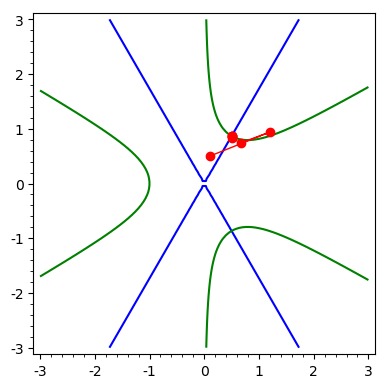

In [54]:
r,k,v = newton(f, df, [0.1,0.5])
ruta(f, v, -3,3, -3,3)

**Exercicio 2:**
1. Pinta las raíces $\mathbf{f}(x,y) = \begin{pmatrix}x^2-y^2+2y\\ 2x+y^2-6\end{pmatrix}$ en $[-5,5]^2$.
2. Calcula una de ellas con `newton`.
3. Pinta el camino seguido por los iterantes.

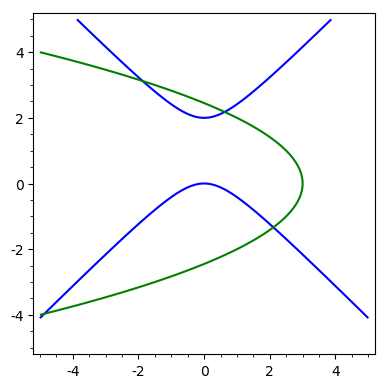

In [41]:
f = lambda x,y: [x^2-y^2+2*y, 2*x+y^2-6]
raices(f)

In [42]:
df = lambda a,b: jacobian(f(x,y),(x,y))(x=a,y=b)
r,k,v = newton(f, df, (4,4))
r,k

((0.625204095212301, 2.179355824452583), 7)

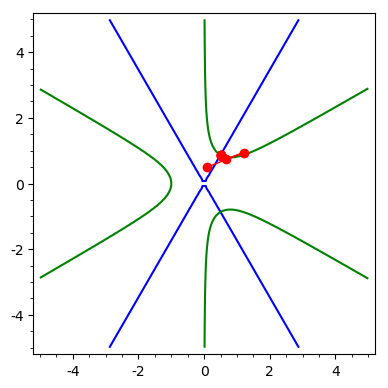

In [55]:
ruta(f, v)

**Exercicio 3:**
1. Procede como en el ejercicio anterior para $\mathbf{f}(x,y) = \begin{pmatrix}3x^2-y^2\\ 3xy^2-x^3-1\end{pmatrix}.$

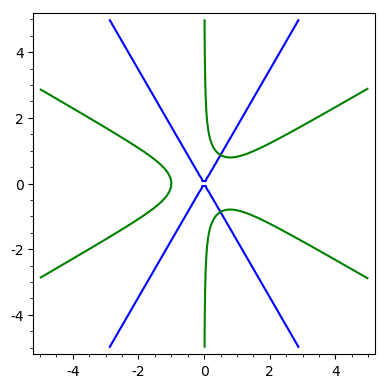

In [44]:
f = lambda x,y: [3*x^2-y^2, 3*x*y^2-x^3-1]
raices(f)

In [45]:
df = lambda a,b: jacobian(f(x,y),(x,y))(x=a,y=b)
r,k,v = newton(f, df, (-2,2))
r,k

((0.5, -0.8660254037844386), 13)

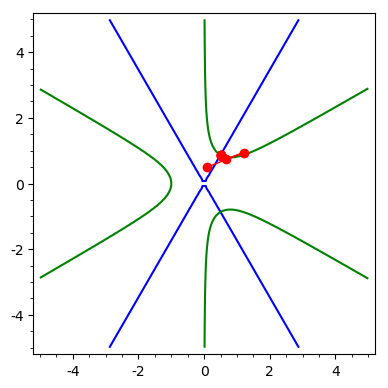

In [56]:
ruta(f, v)

**Ejercicio 4:**
1. Procede como en el ejercicio anterior para 
$\mathbf{f}(x,y) = \begin{pmatrix}\log(x^2+y^2)-\mathrm{sin}(xy)-\log(2)-\log(\pi)\\ \exp(x-y)+\cos(xy)\end{pmatrix}.$

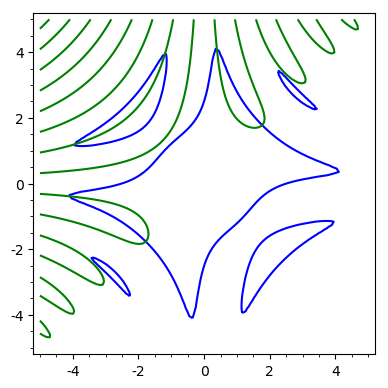

In [47]:
f = lambda x,y: [log(x^2+y^2)-sin(x*y)-log(2)-log(pi), exp(x-y)+cos(x*y)]
raices(f)

In [48]:
df = lambda a,b: jacobian(f(x,y),(x,y))(x=a,y=b)
r,k,v = newton(f, df, (-2,2))
r,k

RuntimeError: La matriz jacobiana es singular en un iterante.

In [49]:
r,k,v = newton(f, df, (4,4))
r,k

((0.38768081205798127, 4.113905543882021), 7)

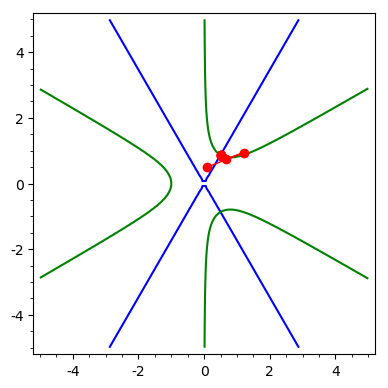

In [57]:
ruta(f, v)

**Ejercicio 5:**
1. Crea una función semejante a `coef_newton` para analizar a converxencia cuadrática del método de Newton multidimensional.

**Solución:**

In [51]:
def coef_newton(f, x0, v):
    """Calcula los coeficientes de convgrxencia de Newton multidimensional."""
    alpha = vector(RDF, fp.findroot(f, x0, tol=9.e-16)) #aproximamos la raíz
    pts = []
    for n in range(len(v)-1):
        if norm(alpha - v[n])^2 > RDF.epsilon():
            pts.append( (n, norm(alpha - v[n+1]) / norm(alpha - v[n])^2 ) )
    return line(pts, marker = '.', title='Coeficientes $C_n$')

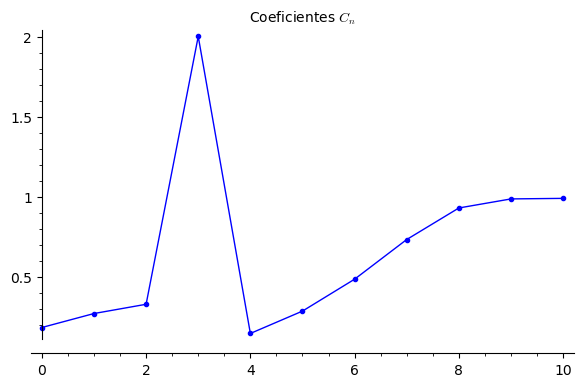

In [52]:
f = lambda x,y: [3*x^2-y^2, 3*x*y^2-x^3-1] # ejercicio 3
df = lambda a,b: jacobian(f(x,y),(x,y))(x=a,y=b)
P = [-2, 2]
r,k,v = newton(f, df, P)
coef_newton(f, P, v)